In [ ]:
# combined/
# How many images?
# How many JSONs?
# Image resolution?
# JSON structure?
# Bounding box format?

In [2]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
DATA_DIR = Path("../Data")

COMBINED_DIR = DATA_DIR / "combined"
SEMANTIC_DIR = DATA_DIR / "semantic_annotations"

print(COMBINED_DIR)
print(SEMANTIC_DIR)

../Data/combined
../Data/semantic_annotations


In [4]:
print("Combined Exists:", COMBINED_DIR.exists())
print("Semantic Exists:", SEMANTIC_DIR.exists())

Combined Exists: True
Semantic Exists: True


## Observation

- total combined and semantic: 2,04,600 -> 1,02,300 image and 1,02,300 json
- Total screenshots: 66,261
- Total hierarchy JSON files: 66,261
- Total semantic annotation files: 66,261

### Conclusion

Every screenshot has:

- one hierarchy annotation
- one semantic annotation

No missing files were found.

In [ ]:
combined_images = list(COMBINED_DIR.glob("*.jpg"))
combined_json = list(COMBINED_DIR.glob("*.json"))


print("Combined Images :", len(combined_images))
print("Combined JSON   :", len(combined_json))

Combined Images : 66261
Combined JSON   : 66261
Semantic JSON   : 66261


## Image Observations

- Images are portrait-oriented.
- Resolution of sample image: 540 × 960.
- Images use RGB color channels.
- Resolution is suitable for object detection and attribute extraction.

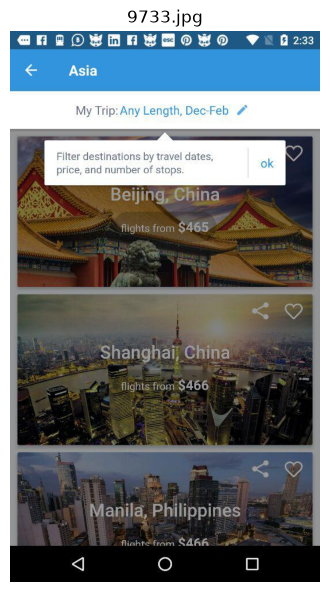

Filename : 9733.jpg
Size     : (540, 960)
Mode     : RGB


In [6]:
sample = combined_images[0]

img = Image.open(sample)

plt.figure(figsize=(4, 8))
plt.imshow(img)
plt.axis("off")
plt.title(sample.name)
plt.show()

print("Filename :", sample.name)
print("Size     :", img.size)
print("Mode     :", img.mode)

In [8]:
sample_json = combined_json[0]

with open(sample_json, "r") as f:
    annotation = json.load(f)

type(annotation)
annotation.keys()

dict_keys(['activity_name', 'activity', 'is_keyboard_deployed', 'request_id'])

In [10]:
print(annotation["activity_name"])
print(annotation["is_keyboard_deployed"])
type(annotation["activity"])

com.siplay.tourneymachine_android/com.siplay.tourneymachine_android.StateSelectActivity
False


dict

In [12]:
annotation["activity"].keys()
type(annotation["activity"]["root"])
annotation["activity"]["root"].keys()

dict_keys(['scrollable-horizontal', 'draw', 'ancestors', 'clickable', 'pressed', 'focusable', 'long-clickable', 'enabled', 'bounds', 'visibility', 'content-desc', 'rel-bounds', 'focused', 'selected', 'scrollable-vertical', 'children', 'adapter-view', 'abs-pos', 'pointer', 'class', 'visible-to-user'])

In [16]:
type(annotation["activity"]["root"]["children"])
len(annotation["activity"]["root"]["children"])

3

In [ ]:
first_child = annotation["activity"]["root"]["children"][0]
first_child.keys()

dict_keys(['scrollable-horizontal', 'draw', 'ancestors', 'clickable', 'pressed', 'focusable', 'long-clickable', 'enabled', 'bounds', 'visibility', 'content-desc', 'rel-bounds', 'focused', 'selected', 'scrollable-vertical', 'children', 'adapter-view', 'abs-pos', 'pointer', 'class', 'visible-to-user'])